# Meteosystem Italy — Proxy Data Download and Preparation

**Pipeline position**: Auxiliary notebook. Runs *before* Notebook 01.

This notebook downloads 30-minute weather data from the Meteosystem website
(www.meteosystem.com) for a specified Italian station, assembles the monthly
CSVs into a single DataFrame, parses the datetime index from the two source
columns (`Data` + `Ora`), and saves the result to `data/raw/proxies/` so that
Notebook 01 can load it with `pd.read_csv(PROXY_FILE, index_col=0, parse_dates=True)`.

## Source schema (Meteosystem Gubbio)

| Raw column | Type | Notes |
|---|---|---|
| `Data` | date string `d/m/yyyy` | Combined with `Ora` to form the datetime index |
| `Ora` | time string `H:MM` | Combined with `Data` |
| `Temp` | float °C | Air temperature |
| `Min` | float °C | Minimum temperature in period |
| `Max` | float °C | Maximum temperature in period |
| `Umid` | int % | Relative humidity |
| `Dew pt` | float °C | Dew-point temperature |
| `Vento` | float m/s | Wind speed |
| `Dir` | string (e.g. `NE`) | Wind direction — compass sector, converted to numeric degrees (see *Wind-direction convention* below) |
| `Raffica` | float m/s | Wind gust speed |
| `Dir Raff.` | string (e.g. `NE`) | Gust direction — compass sector, converted to numeric degrees (same convention as `Dir`) |
| `Press` | float hPa | Atmospheric pressure |
| `Pioggia` | float mm | Precipitation |
| `Int.Pio.` | float | Precipitation intensity |
| `Rad.Sol.` | int W/m² | Solar radiation |

### Wind-direction convention

`Dir` and `Dir Raff.` arrive as 16-point compass sectors (`N`, `NNE`, `NE`,
…, `NNW`). They are converted to numeric bearings in degrees using the
**meteorological convention**: the value is the direction the wind is
blowing *from*, measured clockwise from true north — `N` = 0°, `E` = 90°,
`S` = 180°, `W` = 270°, `NNW` = 337.5°. This is the detail a later reader is
most likely to get backwards (e.g. treating it as the direction the wind
blows *towards*, or measuring counter-clockwise), so it is stated here
explicitly. Because a compass bearing is circular — 350° and 10° are 20°
apart, not 340° — both direction columns are exempted from the linear
outlier and rolling-MAD filters applied in Step 5; see that step's
documentation for how the exemption is implemented.

## Output contract (required by Notebook 01)

| Requirement | Detail |
|---|---|
| **File location** | `data/raw/proxies/{OUTPUT_NAME}.csv` |
| **First column (index)** | `datetime` — ISO 8601, timezone-naive UTC |
| **Index name** | `datetime` |
| **Values** | Numeric only; compass-sector direction columns converted to degrees, other categoricals dropped |

## Steps
1. **Configuration** — Set station URL, date range, output name, and cache settings.
2. **Download** — Fetch missing monthly CSVs from Meteosystem; already-cached months are skipped.
3. **Assemble** — Load all cached chunk files from disk and concatenate into `df_raw`.
4. **Standardise** — Combine datetime columns, convert compass-sector wind-direction columns to numeric degrees, drop any remaining categoricals, and coerce to numeric.
5. **Validate, clean outliers, and plot** — Check coverage, apply global IQR and rolling
   median±MAD outlier filters (with per-column tuning; circular direction columns exempted),
   and plot with internal-gap highlights.
6. **Save** — Write the final proxy CSV if all validations pass.

> **Re-run workflow:** After the first full run of Step 2, you can freely modify and
> re-run Steps 3–6 without re-downloading any data. To download only newly added months,
> extend `END_YEAR` or `START_YEAR` and re-run Step 2 — already-cached months are skipped
> automatically. To force a full re-download, set `FORCE_REDOWNLOAD = True` in Step 1.

> **Jupytext pairing note:** This notebook is paired with `meteosystem_italy.ipynb`
> via the `formats: ipynb,py:percent` header above. The root `jupytext.toml`
> applies globally to all notebooks in the repository, including those in `auxiliary/`.
> Always edit this `.py` file and sync to the notebook via `jupytext --sync` or
> `auto_watcher.py`. Never edit the `.ipynb` directly.

## Imports

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import io
import calendar
import time
import numpy as np
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests
from IPython.display import display
from tqdm.auto import tqdm

from heritageshm.viz import apply_theme, plot_proxy_overview

apply_theme()

## Step 1 · Configuration

### Parameter Tuning Guidance

| Parameter | Type | Description |
|---|---|---|
| `STATION_SLUG` | `str` | Subdirectory in the Meteosystem URL (e.g. `'gubbio'`). Change for a different station. |
| `START_YEAR` | `int` | First year to download (inclusive). |
| `END_YEAR` | `int` | Last year to download (inclusive). |
| `OUTPUT_NAME` | `str` | Base filename written to `data/raw/proxies/`. Set `PROXY_FILE` in Notebook 01 to this path. |
| `DIR_COLUMNS` | `list[str]` | Columns holding 16-point compass-sector wind directions (default `['Dir', 'Dir Raff.']`). Converted in place to numeric degrees (meteorological convention: bearing the wind blows *from*, clockwise from true north — `N` = 0°) before the numeric-coercion step in Step 4. Matching is case-insensitive and whitespace-tolerant; an unrecognised or empty token becomes `NaN`. |
| `COLUMNS_TO_DROP` | `list[str]` | Columns to remove before saving. Empty by default — `Dir` and `Dir Raff.` are now converted to numeric degrees via `DIR_COLUMNS` rather than dropped. Add any unwanted columns here. |
| `TZ_SOURCE` | `str` or `None` | IANA timezone of the raw timestamps. The output index is always timezone-naive UTC. Set to `None` if the source is already UTC. |
| `REQUEST_DELAY` | `float` | Seconds to wait between requests. Keep ≥ 1.0 (minimum — do not lower). |
| `FORCE_REDOWNLOAD` | `bool` | If `True`, re-download every month even if its chunk file already exists in `CACHE_DIR`. Useful after correcting a download bug or updating the station URL. Default: `False`. |

In [10]:
# === USER INPUT ===
STATION_SLUG     = 'gubbio'               # Meteosystem station subdirectory
START_YEAR       = 2018
END_YEAR         = 2026
OUTPUT_NAME      = 'meteosystem_gubbio'   # → saved as data/raw/proxies/meteosystem_gubbio.csv
FORCE_REDOWNLOAD = False                  # True = ignore cache, re-download everything

DIR_COLUMNS     = ['Dir', 'Dir Raff.']    # compass-sector columns converted to numeric degrees
COLUMNS_TO_DROP = []                      # any other unwanted columns; Dir/Dir Raff. now kept

TZ_SOURCE     = 'Europe/Rome'
REQUEST_DELAY = 1.0
# ==================

# Compass-sector → bearing (degrees) lookup for the columns named in DIR_COLUMNS.
# Meteorological convention: the value is the direction the wind is blowing
# FROM, measured clockwise from true north (N = 0°, E = 90°, S = 180°,
# W = 270°). This is the fact about the mapping a later reader is most likely
# to assume backwards, so it is restated here at the point of definition, not
# only in the markdown above.
COMPASS_TO_DEGREES = {
    'N': 0.0,     'NNE': 22.5,  'NE': 45.0,   'ENE': 67.5,
    'E': 90.0,    'ESE': 112.5, 'SE': 135.0,  'SSE': 157.5,
    'S': 180.0,   'SSW': 202.5, 'SW': 225.0,  'WSW': 247.5,
    'W': 270.0,   'WNW': 292.5, 'NW': 315.0,  'NNW': 337.5,
}

BASE_URL    = f'https://www.meteosystem.com/dati/{STATION_SLUG}/csv.php'
OUTPUT_PATH = f'data/raw/proxies/{OUTPUT_NAME}.csv'
CACHE_DIR   = Path(f'data/raw/proxies/_cache/{STATION_SLUG}')

os.makedirs('data/raw/proxies', exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Station      : {STATION_SLUG}')
print(f'Range        : {START_YEAR} – {END_YEAR}')
print(f'Output       : {OUTPUT_PATH}')
print(f'Cache dir    : {CACHE_DIR}')
print(f'Force reload : {FORCE_REDOWNLOAD}')
print(f'Dir columns  : {DIR_COLUMNS}')

Station      : gubbio
Range        : 2018 – 2026
Output       : data/raw/proxies/meteosystem_gubbio.csv
Cache dir    : data\raw\proxies\_cache\gubbio
Force reload : False


## Step 2 · Download Monthly CSVs

Iterates month by month over the configured `START_YEAR`–`END_YEAR` range,
constructs the Meteosystem query URL for each month, and saves the response as
an individual CSV file in `CACHE_DIR`. Months whose cache file already exists
are **skipped** unless `FORCE_REDOWNLOAD = True`.

This means you only ever download each month once. To fetch newly available
months, extend `END_YEAR` and re-run this step — previously downloaded months
are untouched. Steps 3–6 read from the cache and are always safe to re-run
independently.

### Parameter Tuning Guidance

| Parameter | Where set | Description |
|---|---|---|
| `START_YEAR` | Step 1 | First year to download. Extend backwards to retrieve older data. |
| `END_YEAR` | Step 1 | Last year to download. Extend forwards to fetch newly published months. |
| `FORCE_REDOWNLOAD` | Step 1 | Set to `True` to discard all cached CSVs and re-download from scratch (e.g. after a known source correction). |
| `REQUEST_DELAY` | Step 1 | Minimum pause between HTTP requests (seconds). Do not set below `1.0` to avoid server-side rate limiting. |
| `CACHE_DIR` | Derived in Step 1 | Destination folder for monthly CSVs. Change `STATION_SLUG` in Step 1 to redirect the cache to a different sub-directory. |

In [11]:
failed_months = []
n_downloaded  = 0
n_skipped     = 0

yesterday = date.today() - timedelta(days=1)

months_to_process = [
    (year, month)
    for year in range(START_YEAR, END_YEAR + 1)
    for month in range(1, 13)
    if date(year, month, 1) <= yesterday
]

pbar = tqdm(months_to_process, desc='Downloading monthly data')
for year, month in pbar:
    mm       = f'{month:02d}'
    label    = f'{mm}/{year}'
    cache_fp = CACHE_DIR / f'{year}_{mm}.csv'

    if cache_fp.exists() and not FORCE_REDOWNLOAD:
        n_skipped += 1
        pbar.set_postfix_str(f'{label} [cached]')
        continue

    yy = str(year)[-2:]
    _, last_day = calendar.monthrange(year, month)
    month_end   = date(year, month, last_day)
    if month_end > yesterday:
        last_day = yesterday.day

    params = {
        'gg2': '01',               'mm2': mm, 'aa2': yy,
        'gg':  f'{last_day:02d}',  'mm':  mm, 'aa':  yy,
    }

    pbar.set_postfix_str(f'Fetching {label}')

    try:
        response = requests.get(BASE_URL, params=params, timeout=30)
        response.raise_for_status()

        text = response.text.strip()
        if not text:
            continue

        lines     = text.split('\n')
        start_idx = 0
        for i, line in enumerate(lines):
            if line.strip().startswith('Data;'):
                start_idx = i
                break

        clean_text = '\n'.join(lines[start_idx:])

        chunk = pd.read_csv(io.StringIO(clean_text), sep=';')
        if chunk.empty:
            continue

        chunk.to_csv(cache_fp, index=False)
        n_downloaded += 1

    except Exception as exc:
        failed_months.append(label)
        pbar.write(f'  ✗ {label}: {exc}')

    time.sleep(REQUEST_DELAY)

print(f'\nDownload summary')
print(f'  Downloaded : {n_downloaded}')
print(f'  Cached     : {n_skipped}')
print(f'  Failed     : {len(failed_months)}')
if failed_months:
    print(f'  Failed months: {", ".join(failed_months)}')


Download summary
  Downloaded : 0
  Cached     : 92
  Failed     : 0


## Step 3 · Assemble from Cache

Reads every CSV file present in `CACHE_DIR` that falls within the configured
`START_YEAR`–`END_YEAR` range and concatenates them into a single `df_raw`
DataFrame. This step is completely independent of Step 2 — you can re-run it
(and all subsequent steps) at any time without re-downloading anything.

Duplicate rows that may arise from overlapping monthly exports are dropped
before `df_raw` is returned.

### Parameter Tuning Guidance

| Parameter | Where set | Description |
|---|---|---|
| `START_YEAR` | Step 1 | Controls which yearly sub-directories are included in the assembly. Change to narrow or widen the assembled window without touching the cache. |
| `END_YEAR` | Step 1 | Upper bound of the assembled window (inclusive). |
| `CACHE_DIR` | Derived in Step 1 | Source directory scanned for `{year}_{month:02d}.csv` files. |

In [12]:
chunk_files = sorted(
    CACHE_DIR.glob('*.csv'),
    key=lambda p: p.stem
)

def _in_range(fp: Path) -> bool:
    try:
        year, month = (int(x) for x in fp.stem.split('_'))
        return START_YEAR <= year <= END_YEAR
    except ValueError:
        return False

chunk_files = [fp for fp in chunk_files if _in_range(fp)]

assert chunk_files, (
    f'No cache files found in {CACHE_DIR} for {START_YEAR}–{END_YEAR}. '
    'Run Step 2 first to download the data.'
)

all_chunks = [pd.read_csv(fp) for fp in tqdm(chunk_files, desc='Loading cached chunks')]
df_raw = pd.concat(all_chunks, ignore_index=True)
df_raw = df_raw.drop_duplicates()

print(f'\nLoaded {len(chunk_files)} chunk files from cache.')
print(f'Raw shape: {df_raw.shape}')
print(f'\nRaw columns ({len(df_raw.columns)}):')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i:2d}]  {repr(col)}')

display(df_raw.head(3))

Loading cached chunks:   0%|          | 0/92 [00:00<?, ?it/s]


Loaded 92 chunk files from cache.
Raw shape: (137451, 15)

Raw columns (15):
  [ 0]  'Data'
  [ 1]  'Ora'
  [ 2]  'Temp'
  [ 3]  'Min'
  [ 4]  'Max'
  [ 5]  'Umid'
  [ 6]  'Dew pt'
  [ 7]  'Vento'
  [ 8]  'Dir'
  [ 9]  'Raffica'
  [10]  'Dir Raff.'
  [11]  'Press'
  [12]  'Pioggia'
  [13]  'Int.Pio.'
  [14]  'Rad.Sol.'


,Data,Ora,Temp,Min,Max,Umid,Dew pt,Vento,Dir,Raffica,Dir Raff.,Press,Pioggia,Int.Pio.,Rad.Sol.
0,17/10/2018,11:00,18.7,18.7,18.4,74,13.5,8.0,NE,24.1,NE,969.1,0.0,0.0,296
1,17/10/2018,11:30,19.4,19.4,18.7,70,13.4,6.4,NNE,17.7,ENE,969.1,0.0,0.0,342
2,17/10/2018,12:00,20.2,20.2,19.4,69,14.0,4.8,NE,20.9,NNE,968.8,0.0,0.0,353


## Step 4 · Standardise — Datetime Index, Convert Directions, Coerce to Numeric

### Parameter Tuning Guidance

| Parameter | Where set | Description |
|---|---|---|
| `DIR_COLUMNS` | Step 1 | Columns holding 16-point compass-sector wind directions. Converted in place to numeric degrees using `COMPASS_TO_DEGREES` (meteorological convention: bearing the wind blows *from*, clockwise from true north — `N` = 0°). Matching is case-insensitive and whitespace-tolerant; an unrecognised or empty token becomes `NaN`. Runs before the generic numeric-coercion step below. |
| `COLUMNS_TO_DROP` | Step 1 | Add any column names you want to exclude from the output. Empty by default — `Dir` and `Dir Raff.` are handled by `DIR_COLUMNS` instead of being dropped. |
| `TZ_SOURCE` | Step 1 | IANA timezone string for the raw timestamps. Meteosystem Italy serves local time (CET in winter, CEST in summer). Output is always timezone-naive UTC. Set to `None` if the source is already UTC. |

The `Data` and `Ora` columns are combined into a single `datetime` string
before parsing. Both columns are then dropped. The columns named in
`DIR_COLUMNS` are converted from compass sectors to numeric degrees. All
remaining columns are coerced to numeric; non-numeric values become `NaN`.

In [13]:
df = df_raw.copy()

assert 'Data' in df.columns and 'Ora' in df.columns, (
    "Expected columns 'Data' and 'Ora' not found. "
    "Check Step 3 output for the actual date/time column names."
)

df['datetime'] = pd.to_datetime(
    df['Data'].astype(str) + ' ' + df['Ora'].astype(str),
    dayfirst=True,
    errors='coerce',
)
df = df.drop(columns=['Data', 'Ora'])

n_unparsed = df['datetime'].isnull().sum()
if n_unparsed:
    print(f'⚠ {n_unparsed} rows had unparseable datetime values — dropped.')
    df = df.dropna(subset=['datetime'])

if TZ_SOURCE is not None:
    df['datetime'] = (
        df['datetime']
        .dt.tz_localize(TZ_SOURCE, ambiguous='NaT', nonexistent='shift_forward')
        .dt.tz_convert('UTC')
        .dt.tz_localize(None)
    )
    df = df.dropna(subset=['datetime'])
    print(f'Timezone: {TZ_SOURCE} → UTC (timezone-naive)')
else:
    print('Timezone: no conversion applied (assumed UTC).')

df = df.set_index('datetime')
df.index.name = 'datetime'
df = df.sort_index()

cols_to_drop = [c for c in COLUMNS_TO_DROP if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f'Dropped columns    : {cols_to_drop}')

# Convert compass-sector wind-direction columns to numeric degrees before the
# generic numeric-coercion loop below — pd.to_numeric() has no notion of a
# compass sector and would otherwise turn every 'NE', 'SSW', etc. into NaN.
dir_cols_present = [c for c in DIR_COLUMNS if c in df.columns]
if dir_cols_present:
    print(f'Direction columns  : {dir_cols_present}')
for col in dir_cols_present:
    was_missing    = df[col].isnull()
    tokens         = df[col].astype(str).str.strip().str.upper()
    degrees        = tokens.map(COMPASS_TO_DEGREES)
    n_unrecognised = int((degrees.isnull() & ~was_missing).sum())
    df[col]        = degrees
    print(f'  {col:<20}  {n_unrecognised:>6,} unrecognised direction tokens → NaN')

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

non_numeric_remaining = df.select_dtypes(exclude='number').columns.tolist()
if non_numeric_remaining:
    print(f'⚠ Non-numeric columns still present — add to COLUMNS_TO_DROP: {non_numeric_remaining}')

print(f'\nStandardised shape  : {df.shape}')
print(f'Index range         : {df.index.min()}  →  {df.index.max()}')
print(f'Index dtype         : {df.index.dtype}')
print(f'\nFinal columns ({len(df.columns)}):')
for col in df.columns:
    miss = df[col].isnull().mean() * 100
    print(f'  {col:<20}  {miss:5.1f}% missing')

display(df.head(3))

⚠ 9023 rows had unparseable datetime values — dropped.
Timezone: Europe/Rome → UTC (timezone-naive)
Dropped columns    : ['Dir', 'Dir Raff.']

Standardised shape  : (128412, 11)
Index range         : 2018-10-17 09:00:00  →  2026-05-01 22:00:00
Index dtype         : datetime64[ns]

Final columns (11):
  Temp                    0.0% missing
  Min                     0.0% missing
  Max                     0.0% missing
  Umid                    2.9% missing
  Dew pt                  0.0% missing
  Vento                   0.0% missing
  Raffica                 0.0% missing
  Press                   0.0% missing
  Pioggia                 0.0% missing
  Int.Pio.                0.0% missing
  Rad.Sol.                0.0% missing


,Temp,Min,Max,Umid,Dew pt,Vento,Raffica,Press,Pioggia,Int.Pio.,Rad.Sol.
datetime,,,,,,,,,,,
2018-10-17 09:00:00,18.7,18.7,18.4,74.0,13.5,8.0,24.1,969.1,0.0,0.0,296.0
2018-10-17 09:30:00,19.4,19.4,18.7,70.0,13.4,6.4,17.7,969.1,0.0,0.0,342.0
2018-10-17 10:00:00,20.2,20.2,19.4,69.0,14.0,4.8,20.9,968.8,0.0,0.0,353.0


## Step 5 · Validate, Clean Outliers, and Plot

Runs four sub-tasks in sequence:
1. **Structural validation** — checks sorted index, timezone-naive, no all-NaN
   columns, no non-numeric columns, and date-range coverage.
2. **Global IQR filter** — replaces extreme point spikes (values outside
   `Q1 − k·IQR … Q3 + k·IQR` computed over the full series) with `NaN`.
   Columns listed in `DIR_COLUMNS` are skipped explicitly (see below).
3. **Rolling median ± MAD filter** — detects sustained sensor malfunctions
   that produce physically plausible but locally anomalous values. Each column
   uses its own `window` and `factor` resolved from `ROLLING_MAD_OVERRIDES`
   first, then `ROLLING_MAD_DEFAULTS`. Setting a column’s override to `None`
   **excludes** it from this filter entirely (recommended for signals with a
   strong diurnal zero cycle such as `Rad.Sol.`, and for the circular
   direction columns in `DIR_COLUMNS`).
4. **Overview plot** — plots selected columns with internal-gap bands.

### Why per-column overrides are needed

`Rad.Sol.` legitimately hits 0 W/m² every night and ~800–1000 W/m² every
midday. A rolling median over any window that spans both day and night will
sit at a mid-range value, making every night-time zero look like an extreme
downward deviation. The same issue affects highly variable columns such as
`Vento` and `Raffica`. The per-column override mechanism lets you skip or
loosen the filter for these columns while keeping it tight for slowly-varying
ones like `Temp` and `Press`.

`Dir` and `Dir Raff.` need the same treatment for a different reason: they
are **circular** data. 350° and 10° are 20° apart on a compass, not 340°
apart as a linear filter would compute, so a rolling median±MAD test would
treat a legitimate shift across due north as an extreme deviation. That
filter is skipped for them through the same `ROLLING_MAD_OVERRIDES = None`
mechanism used for `Rad.Sol.`. The global IQR filter has no equivalent
per-column override, so the direction columns are skipped there with a
small explicit check inlined in that filter's loop (see the comment at
that line in the code cell below).

### Parameter Tuning Guidance

| Parameter | Type | Default | Description |
|---|---|---|---|
| `PLOT_COLS` | `list[str]` or `None` | `None` | Columns to include in the overview plot. `None` = all columns. |
| `APPLY_IQR_FILTER` | `bool` | `True` | Enable/disable the global IQR spike filter. |
| `OUTLIER_IQR_FACTOR` | `float` | `5.0` | IQR multiplier for global fences. Lower = more aggressive. |
| `APPLY_ROLLING_MAD_FILTER` | `bool` | `True` | Enable/disable the rolling MAD filter entirely. |
| `ROLLING_MAD_DEFAULTS` | `dict` | `{'window': 336, 'factor': 6.0, 'floor': 0.1}` | Fallback parameters applied to every column not listed in `ROLLING_MAD_OVERRIDES`. `window` is in rows (336 = 7 days × 48 steps). `factor` is the MAD multiplier. `floor` is the minimum MAD (prevents division-by-zero on flat runs). |
| `ROLLING_MAD_OVERRIDES` | `dict[str, dict or None]` | see below | Per-column parameter overrides. Use a `dict` with any subset of `window`/`factor`/`floor` keys to override defaults for that column. Set to `None` to **skip** the filter for that column entirely. |
| `HIGHLIGHT_GAPS` | `bool` | `True` | Whether to shade internal NaN runs in the overview plot. |

⚠ Dataset starts 2018-10-17 09:00:00, later than expected 2018-01-01 00:00:00.

⚠ Some checks failed — review warnings above before saving.

Final dataset: 128,412 rows × 11 columns

── Global IQR filter (IQR × 5.0) ──
  Umid                       2 outliers → NaN  (fence: [-102, 239])
  Dew pt                     3 outliers → NaN  (fence: [-48.2, 64])
  Vento                      3 outliers → NaN  (fence: [-32, 38.4])
  Raffica                    2 outliers → NaN  (fence: [-59.7, 82.2])
  Press                      3 outliers → NaN  (fence: [919, 1.02e+03])
  Rad.Sol.                   1 outliers → NaN  (fence: [-1.03e+03, 1.24e+03])
  Total replaced: 14 values

── Rolling median±MAD filter (per-column parameters) ──
  Temp                     179 anomalous values → NaN  (window=336, factor=6.0)
  Min                      195 anomalous values → NaN  (window=336, factor=6.0)
  Max                      184 anomalous values → NaN  (window=336, factor=6.0)
  Umid                     600 a

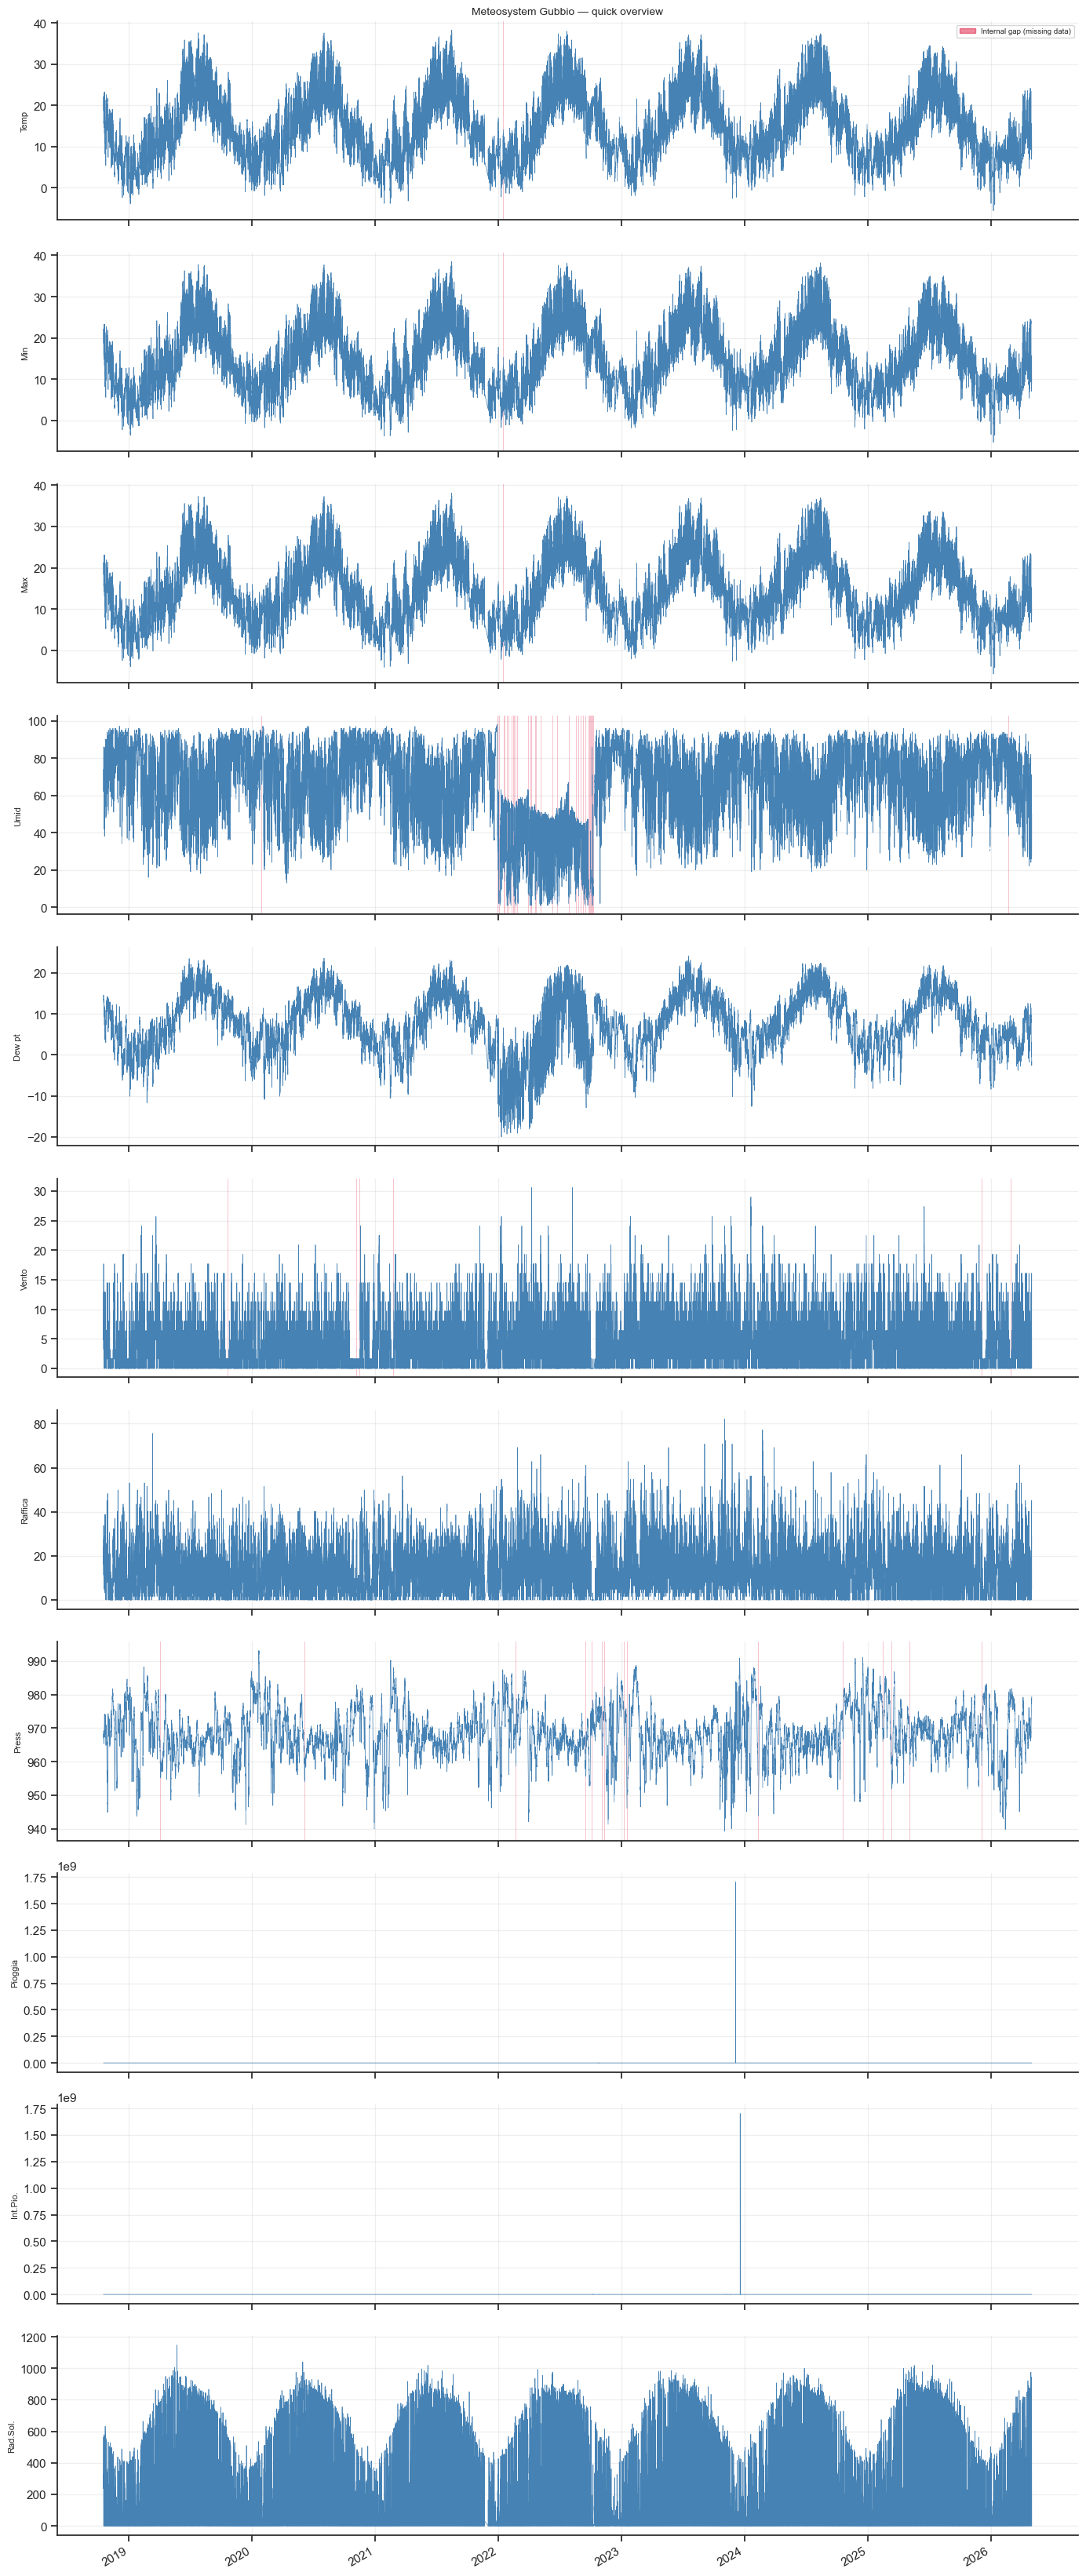

In [14]:
# === USER INPUT ===
PLOT_COLS              = None   # e.g. ['Temp', 'Umid', 'Rad.Sol.'] or None for all

APPLY_IQR_FILTER       = True   # global spike filter
OUTLIER_IQR_FACTOR     = 5.0    # IQR fence multiplier

APPLY_ROLLING_MAD_FILTER = True  # rolling local-context filter (master switch)

# Default rolling-MAD parameters applied to every column not listed in overrides.
ROLLING_MAD_DEFAULTS = {
    'window': 336,   # 7 days × 48 rows/day
    'factor': 6.0,   # threshold = local_median ± factor × MAD
    'floor':  0.1,   # minimum MAD (variable units)
}

# Per-column overrides.  Any key absent from the dict falls back to ROLLING_MAD_DEFAULTS.
# Set a column to None to SKIP the rolling-MAD filter for that column entirely.
#
# Reasoning for the pre-set values:
#   Rad.Sol.  → None    : strong diurnal 0→peak cycle confuses rolling median;
#                          rely on global IQR only for this column.
#   Vento     → factor 10: wind is inherently bursty; a tighter factor causes
#                          legitimate gusts to be flagged as anomalies.
#   Raffica   → factor 10: same reason as Vento.
#   Pioggia   → None    : precipitation is zero-inflated; rolling median is
#                          almost always 0, making MAD unreliable.
#   Int.Pio.  → None    : same reason as Pioggia.
#   Dir       → None    : circular compass-degree data (0° wraps to 360°); a
#                          linear median±MAD test would treat a legitimate
#                          shift across due north as an extreme outlier.
#   Dir Raff. → None    : same reason as Dir.
ROLLING_MAD_OVERRIDES = {
    'Rad.Sol.':  None,
    'Vento':     {'factor': 10.0},
    'Raffica':   {'factor': 10.0},
    'Pioggia':   None,
    'Int.Pio.':  None,
    'Dir':       None,
    'Dir Raff.': None,
}

# Belt-and-braces: whatever DIR_COLUMNS is configured to in Step 1, every
# column it names is exempted from the rolling-MAD filter here. Circularity
# is a property of the data type, not a per-run choice, so this must hold
# even if a user renames or extends DIR_COLUMNS without touching this dict.
for col in DIR_COLUMNS:
    ROLLING_MAD_OVERRIDES.setdefault(col, None)

HIGHLIGHT_GAPS = True
# ==================

validation_ok = True

# ------------------------------------------------------------------
# 1. Structural validation
# ------------------------------------------------------------------
assert isinstance(df.index, pd.DatetimeIndex), 'Index is not a DatetimeIndex.'

if not df.index.is_monotonic_increasing:
    print('⚠ Index not sorted — sorting now.')
    df = df.sort_index()

if df.index.tz is not None:
    print('⚠ Index has timezone info — stripping to naive UTC.')
    df.index = df.index.tz_localize(None)

all_nan = [c for c in df.columns if df[c].isnull().all()]
if all_nan:
    print(f'⚠ Entirely-NaN columns dropped: {all_nan}')
    df = df.drop(columns=all_nan)

non_num = df.select_dtypes(exclude='number').columns.tolist()
if non_num:
    print(f'⚠ Non-numeric columns still present (add to COLUMNS_TO_DROP): {non_num}')
    validation_ok = False

yesterday_ts   = pd.Timestamp.today().normalize() - pd.Timedelta(days=1)
expected_start = pd.Timestamp(f'{START_YEAR}-01-01')
expected_end   = min(pd.Timestamp(f'{END_YEAR}-12-31'), yesterday_ts)

if df.index.min() > expected_start:
    print(f'⚠ Dataset starts {df.index.min()}, later than expected {expected_start}.')
    validation_ok = False
if df.index.max() < expected_end:
    print(f'⚠ Dataset ends {df.index.max()}, earlier than expected {expected_end}.')
    validation_ok = False

if validation_ok:
    print('✓ All structural validation checks passed.')
else:
    print('\n⚠ Some checks failed — review warnings above before saving.')

print(f'\nFinal dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ------------------------------------------------------------------
# 2. Global IQR filter — catches extreme point spikes
# ------------------------------------------------------------------
if APPLY_IQR_FILTER:
    print(f'\n── Global IQR filter (IQR × {OUTLIER_IQR_FACTOR}) ──')
    total_replaced = 0
    iqr_skipped_dir_cols = [c for c in DIR_COLUMNS if c in df.columns]
    for col in df.columns:
        if col in DIR_COLUMNS:
            # Wind direction is circular (0° wraps to 360°): a linear IQR
            # fence has no notion of that wrap-around and would flag
            # legitimate winds near due north as spikes. There is no
            # per-column override mechanism for this filter (unlike the
            # rolling-MAD filter below), so the skip is inlined here.
            continue
        q1  = df[col].quantile(0.25)
        q3  = df[col].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower = q1 - OUTLIER_IQR_FACTOR * iqr
        upper = q3 + OUTLIER_IQR_FACTOR * iqr
        mask  = (df[col] < lower) | (df[col] > upper)
        n_out = int(mask.sum())
        if n_out > 0:
            df.loc[mask, col] = np.nan
            total_replaced += n_out
            print(f'  {col:<20}  {n_out:>6,} outliers → NaN  (fence: [{lower:.3g}, {upper:.3g}])')
    if total_replaced == 0:
        print('  ✓ No outliers detected in any column.')
    else:
        print(f'  Total replaced: {total_replaced:,} values')
    if iqr_skipped_dir_cols:
        print(f'  Skipped (circular direction data): {", ".join(iqr_skipped_dir_cols)}')
else:
    print('\n── Global IQR filter skipped (APPLY_IQR_FILTER = False) ──')

# ------------------------------------------------------------------
# 3. Rolling median ± MAD filter — catches sustained malfunctions
#
# For each column the filter resolves its parameters by merging
# ROLLING_MAD_DEFAULTS with the column's entry in ROLLING_MAD_OVERRIDES
# (if any). A column whose override is None is skipped entirely.
#
# For each processed column:
#   a) Compute a centred rolling median over `window` rows.
#   b) Compute the rolling MAD over the same window.
#   c) Clamp MAD to max(floor, 10% of global-median MAD) so that flat-line
#      artefacts and low-variance columns are handled correctly.
#   d) Flag values where |value - rolling_median| > factor * clamped_MAD.
# ------------------------------------------------------------------
if APPLY_ROLLING_MAD_FILTER:
    print(f'\n── Rolling median±MAD filter (per-column parameters) ──')
    total_replaced = 0
    skipped_cols   = []

    for col in df.columns:
        # Resolve override: None means skip; missing key means use defaults.
        override = ROLLING_MAD_OVERRIDES.get(col, {})   # {} = not listed
        if override is None:
            skipped_cols.append(col)
            continue

        # Merge defaults with any per-column overrides.
        params  = {**ROLLING_MAD_DEFAULTS, **override}
        window  = params['window']
        factor  = params['factor']
        floor   = params['floor']

        s = df[col]
        if s.isnull().all():
            continue

        min_periods = window // 4
        roll        = s.rolling(window=window, center=True, min_periods=min_periods)
        roll_median = roll.median()
        roll_mad    = (s - roll_median).abs().rolling(
                          window=window, center=True, min_periods=min_periods
                      ).median()

        global_mad_median = roll_mad.median()
        effective_floor   = max(floor, global_mad_median * 0.1)
        roll_mad_clamped  = roll_mad.clip(lower=effective_floor)

        threshold = factor * roll_mad_clamped
        deviation = (s - roll_median).abs()
        mask      = (deviation > threshold) & roll_mad_clamped.notna()

        n_out = int(mask.sum())
        if n_out > 0:
            df.loc[mask, col] = np.nan
            total_replaced += n_out
            print(f'  {col:<20}  {n_out:>6,} anomalous values → NaN  '
                  f'(window={window}, factor={factor})')

    if total_replaced == 0:
        print('  ✓ No sustained anomalies detected in any processed column.')
    else:
        print(f'  Total replaced: {total_replaced:,} values')
    if skipped_cols:
        print(f'  Skipped (override=None): {", ".join(skipped_cols)}')
else:
    print('\n── Rolling MAD filter skipped (APPLY_ROLLING_MAD_FILTER = False) ──')

# ------------------------------------------------------------------
# 4. Overview plot — gap bands rendered inside plot_proxy_overview
# ------------------------------------------------------------------
df_plot = df[PLOT_COLS] if PLOT_COLS is not None else df
plot_proxy_overview(
    df_plot,
    station_slug=STATION_SLUG,
    highlight_gaps=HIGHLIGHT_GAPS,
)

## Step 6 · Save

Saves the dataset to `data/raw/proxies/{OUTPUT_NAME}.csv`.
The datetime index is written as the first column so Notebook 01 can load it
with `pd.read_csv(PROXY_FILE, index_col=0, parse_dates=True)`.

**In Notebook 01 Step 2, set:**
```python
PROXY_FILE = 'data/raw/proxies/{OUTPUT_NAME}.csv'
```
Then in Step 3, choose columns from the list printed in Step 4 above
(e.g. `'Temp'`, `'Umid'`, `'Dew pt'`, `'Rad.Sol.'`, etc.).

> To force-save despite validation warnings, replace `if validation_ok:` with `if True:`.

In [ ]:
if True:
    df.to_csv(OUTPUT_PATH, index=True)
    print(f'✓ Proxy saved to : {OUTPUT_PATH}')
    print(f'  Shape          : {df.shape}')
    print(f'  Index range    : {df.index.min()}  →  {df.index.max()}')
    print(f'\nIn Notebook 01, set:')
    print(f"  PROXY_FILE = '{OUTPUT_PATH}'")
    print(f'\nAvailable columns for PROXY_COLS in Notebook 01 Step 3:')
    for col in df.columns:
        print(f"  '{col}'")
else:
    print('Save skipped — resolve validation warnings above before saving.')
    print('To force-save despite warnings, replace `if validation_ok:` with `if True:`.')